# FinSight — Executive Cloud Intelligence Layer
### Reproducible walkthrough · Capacity-Mngt-App + Cost-Mngt-App + RAG

**Capstone proof-of-work** for *UC Berkeley Executive Education — AI & GenAI: Business Strategies and Applications*.

FinSight unifies two production-style AIOps engines behind a retrieval-augmented conversational layer so a CXO or PE investor can ask, in plain English, *“are we going to run out of capacity, and why did our bill move?”* and get a **grounded, cited** answer.

| Engine | Question | Technique (Berkeley module) |
|---|---|---|
| **Capacity-Mngt-App** | *Will we run out of headroom? What will it cost?* | Supervised time-series forecasting (Module 2 — predictive) |
| **Cost-Mngt-App** | *Where did the money go? Is it a problem?* | Unsupervised anomaly detection + attribution (Module 2/3) |
| **RAG layer** | *Answer my question in plain English, with proof* | Retrieval-augmented generation (Modules 4 / 7–8) |

> **Grounding contract:** the deterministic engines own every number; the language model only phrases them. The RAG layer can cite *only* facts the engines computed.

Everything below is deterministic (`seed=42`) and uses **synthetic** data modeled on a representative Enterprise CX SaaS estate (167 AWS deployments, ~$5M annual spend). No production data.

In [1]:
import sys; sys.path.insert(0, '../src')
import pandas as pd
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

from finsight import (
    generate, annualized_spend,
    forecast_capacity, forecast_cost,
    CostMngtApp,
    build_corpus, FinSightRAG,
)

## 1. The data

Synthetic daily AWS billing + utilization for three product lines (Engage, Analyze, Assist) across four regions and seven services. The generator injects trend, weekly seasonality, month-boundary billing bumps, five realistic cost **anomalies**, and one deliberate capacity **pressure ramp** (Assist / us-east-1).

In [2]:
cost, util = generate(seed=42)
print(f'Annualized estate spend : ${annualized_spend(cost):,.0f}')
print(f'Cost line-items         : {len(cost):,}')
print(f'Utilization records     : {len(util):,}')
print(f'Injected cost anomalies : {cost["anomaly_cause"].notna().sum()} line-items')
cost.head()

Annualized estate spend : $4,974,095
Cost line-items         : 15,120
Utilization records     : 2,160
Injected cost anomalies : 15 line-items


,date,product,tenancy,region,service,cost_usd,anomaly_cause
0,2025-01-01,Engage,MT,us-east-1,EKS-Compute,"1,015.80",NaN
1,2025-01-02,Engage,MT,us-east-1,EKS-Compute,948.90,NaN
2,2025-01-03,Engage,MT,us-east-1,EKS-Compute,980.10,NaN
3,2025-01-04,Engage,MT,us-east-1,EKS-Compute,811.36,NaN
4,2025-01-05,Engage,MT,us-east-1,EKS-Compute,699.59,NaN


## 2. Capacity-Mngt-App — predictive capacity & cost forecasting

A ridge-regularized linear model on engineered temporal features (trend, day-of-week one-hots, weekly Fourier terms). Interpretable, fast, reproducible, and the residual variance gives an honest prediction interval. We ask it the executive's forward question: *will Assist in us-east-1 breach the 80% headroom threshold?*

In [3]:
fc = forecast_capacity(util, 'Assist', 'us-east-1', horizon=45, threshold_pct=80.0)
print(fc.summary())

Capacity-Mngt-App forecast — Assist / us-east-1 utilization
  horizon            : 45 days
  projected end value: 95.0%
  in-sample MAE      : 1.97%
  in-sample MAPE     : 2.7%
  status             : CRITICAL
  ALREADY OVER 80% (current 81.6%) — act now


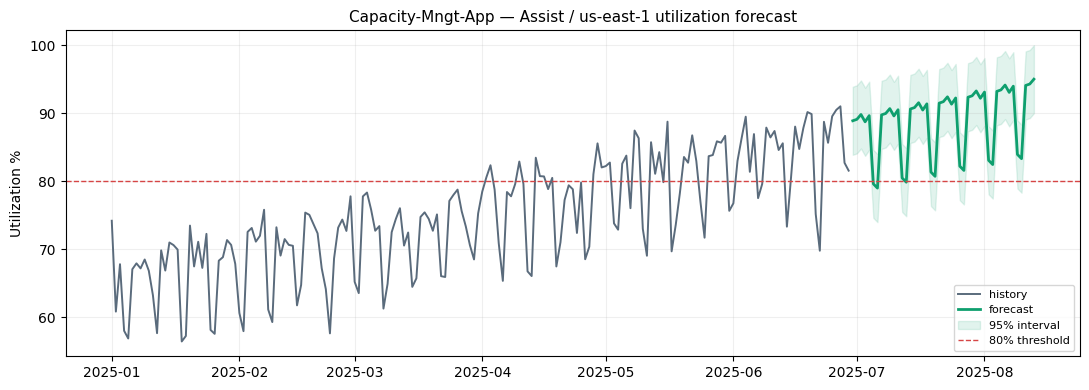

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
h, f = fc.history, fc.forecast
ax.plot(h['date'], h['value'], color='#5A6B7C', lw=1.4, label='history')
ax.plot(f['date'], f['yhat'], color='#0E9F6E', lw=2, label='forecast')
ax.fill_between(f['date'], f['lower'], f['upper'], color='#0E9F6E', alpha=0.12, label='95% interval')
ax.axhline(80, color='#D64545', ls='--', lw=1, label='80% threshold')
ax.set_title('Capacity-Mngt-App — Assist / us-east-1 utilization forecast', fontsize=11)
ax.set_ylabel('Utilization %'); ax.legend(fontsize=8, loc='lower right'); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

In [5]:
# Estate-wide capacity scan: which streams are at risk?
rows = []
for prod in sorted(cost['product'].unique()):
    for region in sorted(cost['region'].unique()):
        s = forecast_capacity(util, prod, region)
        rows.append((prod, region, round(s.current_value,1), s.status))
scan = pd.DataFrame(rows, columns=['product','region','current_util_%','status'])
scan.sort_values(['status','current_util_%'], ascending=[True, False]).head(8)

,product,region,current_util_%,status
6,Assist,us-east-1,81.60,CRITICAL
1,Analyze,eu-west-1,65.70,HEALTHY
10,Engage,us-east-1,65.30,HEALTHY
5,Assist,eu-west-1,65.10,HEALTHY
3,Analyze,us-west-2,64.90,HEALTHY
2,Analyze,us-east-1,64.80,HEALTHY
7,Assist,us-west-2,64.30,HEALTHY
0,Analyze,ap-southeast-1,62.60,HEALTHY


## 3. Cost-Mngt-App — cost anomaly detection & attribution

Detection uses a **robust z-score** on a rolling median + MAD baseline per (product, region, service) stream. MAD-based scoring resists the very spikes we're hunting, so the baseline doesn't get poisoned. Transparent by design — finance and engineering must see *why* a charge was flagged.

In [6]:
cf = CostMngtApp(z_threshold=4.0)
anomalies = cf.detect(cost)
print(f'{len(anomalies)} anomalies detected, ${anomalies["excess_usd"].sum():,.0f} total excess spend\n')
anomalies[['date','product','region','service','cost_usd','baseline_usd','excess_usd','robust_z','suspected_cause']].head(8)

51 anomalies detected, $4,734 total excess spend



,date,product,region,service,cost_usd,baseline_usd,excess_usd,robust_z,suspected_cause
0,2025-06-22,Engage,us-east-1,EKS-Compute,"1,533.30",970.97,562.34,10.32,Black-Friday-style load test not torn down
1,2025-06-22,Assist,us-east-1,EKS-Compute,"1,316.67",756.63,560.04,10.92,Black-Friday-style load test not torn down
2,2025-06-22,Analyze,us-east-1,EKS-Compute,"1,211.77",759.66,452.11,5.87,Black-Friday-style load test not torn down
3,2025-02-17,Engage,us-east-1,DataTransfer,585.26,179.87,405.39,23.66,Cross-AZ chatter from mis-scheduled MT replica...
4,2025-02-17,Analyze,us-east-1,DataTransfer,475.41,137.22,338.19,21.37,Cross-AZ chatter from mis-scheduled MT replica...
5,2025-02-17,Assist,us-east-1,DataTransfer,425.26,117.68,307.58,24.08,Cross-AZ chatter from mis-scheduled MT replica...
6,2025-05-04,Engage,eu-west-1,RDS,409.28,159.30,249.98,22.81,Orphaned read-replica left running after a fai...
7,2025-05-04,Assist,eu-west-1,RDS,359.82,114.82,245.00,42.54,Orphaned read-replica left running after a fai...


In [7]:
# Attribution: explain the spend delta, last 14 days vs the prior 14, by service
dates = sorted(cost['date'].unique())
recent = (str(pd.Timestamp(dates[-14]).date()), str(pd.Timestamp(dates[-1]).date()))
prior  = (str(pd.Timestamp(dates[-28]).date()), str(pd.Timestamp(dates[-15]).date()))
cf.attribute(cost, prior, recent, dimension='service')

,service,period_a_per_day,period_b_per_day,delta_per_day,pct_of_change
0,EKS-Compute,"5,312.58","5,456.24",143.66,99.18
1,EC2,"2,644.79","2,650.33",5.53,3.82
2,Lambda,703.36,699.62,-3.74,-2.58
3,DataTransfer,977.91,975.29,-2.62,-1.81
4,S3,"1,172.34","1,174.77",2.43,1.68
5,RDS,"2,067.67","2,067.00",-0.68,-0.47
6,Observability,"1,328.78","1,329.05",0.27,0.19


## 4. The grounding corpus

The RAG layer does **not** index 15,000 raw billing rows. It indexes the *derived* facts the engines produced — each a short, atomic, cited statement. This keeps retrieval relevant and guarantees the LLM can only cite real computed numbers.

In [8]:
cards = build_corpus(cost, util)
print(f'{len(cards)} fact cards built from engine outputs\n')
for c in cards[:6]:
    print(f'[{c.id} | {c.source}] {c.text}\n')

32 fact cards built from engine outputs

[FACT-000 | Estate] The total cloud estate is tracking to $4,974,095 annualized spend, with the most recent day at $13,043.

[FACT-001 | Estate] Engage accounts for $974,317 of cumulative spend (39.7% of the estate over the observed window).

[FACT-002 | Estate] Analyze accounts for $775,801 of cumulative spend (31.6% of the estate over the observed window).

[FACT-003 | Estate] Assist accounts for $702,860 of cumulative spend (28.7% of the estate over the observed window).

[FACT-004 | Estate] us-east-1 is the largest region by spend at $1,129,429 (46.0% of the estate).

[FACT-005 | Capacity-Mngt-App] Capacity-Mngt-App projects estate daily spend will reach $15,147 per day in 45 days (forecast MAPE 1.2%), implying roughly $5,528,713 annualized if the trend holds.



## 5. FinSight RAG — grounded executive Q&A

TF-IDF retrieval over the fact corpus → grounded composition. With `ANTHROPIC_API_KEY` set, Claude phrases the answer under a strict grounding system prompt; without it, a deterministic template stitches the retrieved facts together. **The repo always runs**; a key just makes the prose fluent.

In [9]:
rag = FinSightRAG(cost, util)

for q in [
    'Will we run out of capacity anywhere in the next quarter?',
    'Why did our cloud spend spike, and where?',
    'What is our annualized cloud spend and what is driving it?',
]:
    ans = rag.ask(q)
    print('Q:', q)
    print('A:', ans.answer)
    print('Citations:', ', '.join(ans.citations), '| LLM:', ans.used_llm)
    print('-'*100)

Q: Will we run out of capacity anywhere in the next quarter?
A: Assist in us-east-1 is ALREADY above the 80% utilization headroom threshold (current ~82%). Capacity-Mngt-App status: CRITICAL — capacity action is needed now. [FACT-012] Recommended action: rightsize or scale the affected workload now and re-baseline the headroom alert.
Citations: FACT-012 | LLM: False
----------------------------------------------------------------------------------------------------
Q: Why did our cloud spend spike, and where?
A: On 2025-06-01, Observability spend for Engage in us-west-2 hit $280 versus a $115 baseline (+$165, robust z=25.0). Suspected cause: Debug log verbosity shipped to prod, Datadog ingest spike. [FACT-029] The total cloud estate is tracking to $4,974,095 annualized spend, with the most recent day at $13,043. [FACT-000]
Citations: FACT-000, FACT-029 | LLM: False
----------------------------------------------------------------------------------------------------
Q: What is our annual

## 6. The grounding contract, demonstrated

Every FACT id the answer cites exists in the corpus, and an off-domain question is declined rather than answered with dressed-up irrelevant facts. This is the anti-hallucination guarantee that makes the assistant safe to put in front of finance.

In [10]:
import re
valid = {c.id for c in rag.cards}
ans = rag.ask('Why did spend spike?')
cited = set(re.findall(r'FACT-\d{3}', ans.answer))
print('Cited ids:', cited)
print('All cited ids are real:', cited <= valid)

off = rag.ask('What is the airspeed velocity of an unladen swallow?')
print('\nOff-domain question → citations:', off.citations or 'none (declined)')
print('Answer:', off.answer)

Cited ids: {'FACT-029'}
All cited ids are real: True

Off-domain question → citations: none (declined)
Answer: I don't have a grounded fact that answers that. Try asking about estate spend, a product/region's capacity headroom, or recent cost anomalies — Capacity-Mngt-App and Cost-Mngt-App cover those.


## 7. Run the executive cockpit

The same engines power a FastAPI + HTML cockpit:

```bash
pip install -r requirements.txt
export ANTHROPIC_API_KEY=sk-...   # optional — enables fluent LLM answers
uvicorn api.main:app --reload --port 8000
# open http://localhost:8000
```

The cockpit surfaces the KPI strip, the Capacity-Mngt-App capacity table, the Cost-Mngt-App anomaly feed, the spend forecast, and the *Ask FinSight* box — every answer rendered with its inline `[FACT-xxx]` citations and the evidence it retrieved.